# 06-Incremental Data Loading Physics

In Lesson 05, we mastered Advanced Airflow Orchestration. We learned how to schedule tasks and dynamically route computational graphs.

However, running a scheduled pipeline exposes a massive physical limitation: **The Full-Table Scan Bottleneck**.
If your `fact_sales` table contains 5 billion rows (petabytes of data), running `CREATE OR REPLACE TABLE AS SELECT * FROM source` every night at 2:00 AM is mathematically impossible. It will consume catastrophic amounts of cloud compute, saturate your network bandwidth, and ultimately timeout.

To scale Enterprise data systems, we must transition from **Full Refresh** architectures to **Incremental Loading** architectures. We must only query the data that has changed ($\Delta D$) since the last time the pipeline ran.

Let's set up our engine to architect the physics of the Incremental Load.

In [6]:
# Required installations: pip install duckdb pandas matplotlib seaborn
import duckdb
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Incremental Loading Engine Operational.")

✅ Systems Architecture & Incremental Loading Engine Operational.


# 1. The Mathematics of Incremental State ($H_t$)

In a Full Refresh pipeline, the state of the target data warehouse at time $t$ ($W_t$) is a complete overwrite of the source database ($S_t$):


$$W_t = S_t$$

In an Incremental pipeline, we introduce a temporal state variable known as the **High-Water Mark** ($H_t$). $H_t$ represents the exact maximum timestamp of the data successfully processed in the previous run.

During execution, the extraction query is mathematically bounded by this variable:


$$\Delta S_t = \{ x \in S_t \mid x_{timestamp} > H_{t-1} \}$$

The warehouse state is then mutated using a non-destructive union of the previous state and the new delta:


$$W_t = W_{t-1} \cup \Delta S_t$$

### The Threat of Duplication & The UPSERT Operator

If $\Delta S_t$ contains a row that already exists in $W_{t-1}$ (e.g., an order status was updated from 'Pending' to 'Shipped'), a standard `INSERT` will create a duplicate row, destroying the integrity of your analytical metrics.

To ensure **Idempotency** (the mathematical guarantee that running the pipeline 100 times yields the exact same result as running it once), we use the **UPSERT** operator (`INSERT ... ON CONFLICT DO UPDATE`). This guarantees that primary keys remain unique.

# 2. Architecting the High-Water Mark Engine

Let's build a real, executable incremental pipeline in DuckDB.
We will:

1. Create a **Source Database** (simulating a production Postgres app).
2. Create a **Target Warehouse** with a strict Primary Key.
3. Create a **Watermark Control Table** to store $H_t$.
4. Execute an autonomous incremental load that gracefully handles both new inserts and existing updates without duplicating data.

In [7]:
# Initialize physical warehouse connection
conn = duckdb.connect('incremental_engine.db')

# --- 🪵 STEP 1: Initialize the Ecosystem ---

# 1A. The Source Database (Production Application)
conn.execute("DROP TABLE IF EXISTS source_orders;")
conn.execute("""
    CREATE TABLE source_orders (
        order_id INT,
        status VARCHAR,
        updated_at TIMESTAMP
    );
""")
# Insert Initial Data (Day 1)
conn.execute("""
    INSERT INTO source_orders VALUES
    (1, 'Pending', '2026-06-24 10:00:00'),
    (2, 'Shipped', '2026-06-24 11:00:00');
""")

# 1B. The Target Warehouse (Analytical DB)
# CRITICAL: We MUST define a PRIMARY KEY to mathematically enable UPSERTs
conn.execute("DROP TABLE IF EXISTS target_orders;")
conn.execute("""
    CREATE TABLE target_orders (
        order_id INT PRIMARY KEY,
        status VARCHAR,
        updated_at TIMESTAMP
    );
""")

# 1C. The Watermark Control Table (The Memory of the Pipeline)
conn.execute("DROP TABLE IF EXISTS watermark_journal;")
conn.execute("""
    CREATE TABLE watermark_journal (
        table_name VARCHAR PRIMARY KEY,
        high_water_mark TIMESTAMP
    );
""")
# Initialize the state to the beginning of Unix time
conn.execute("INSERT INTO watermark_journal VALUES ('target_orders', '1970-01-01 00:00:00');")

Now, we write the Python execution logic that acts as our Airflow Task. It reads the mathematical state, dynamically constructs the Delta query, and safely mutates the warehouse.

In [8]:
# --- ⚙️ STEP 2: The Incremental Execution Function ---

def run_incremental_load(db_conn, target_table: str, source_table: str):
    print(f"\n🚀 [PIPELINE START] Executing Incremental Load for '{target_table}'...")
    
    # A. Retrieve the High-Water Mark ($H_{t-1}$)
    watermark_query = f"SELECT high_water_mark FROM watermark_journal WHERE table_name = '{target_table}'"
    h_t_minus_1 = db_conn.execute(watermark_query).fetchone()[0]
    print(f"   🌊 [STATE] Pulled High-Water Mark: {h_t_minus_1}")
    
    # B. The Idempotent UPSERT Logic
    # We only extract rows strictly greater than the watermark.
    # If the Primary Key (order_id) clashes, we overwrite the existing row.
    upsert_sql = f"""
        INSERT INTO {target_table}
        SELECT * FROM {source_table} 
        WHERE updated_at > '{h_t_minus_1}'
        
        ON CONFLICT (order_id) DO UPDATE SET
            status = EXCLUDED.status,
            updated_at = EXCLUDED.updated_at;
    """
    
    # Execute the physical mutation
    result = db_conn.execute(upsert_sql)
    rows_affected = result.fetchall() # DuckDB returns rows affected for inserts
    
    # C. Advance the State ($H_t$)
    # We find the absolute maximum timestamp currently existing in the target table
    advance_state_sql = f"""
        UPDATE watermark_journal 
        SET high_water_mark = (SELECT COALESCE(MAX(updated_at), '{h_t_minus_1}') FROM {target_table})
        WHERE table_name = '{target_table}';
    """
    db_conn.execute(advance_state_sql)
    
    new_watermark = db_conn.execute(watermark_query).fetchone()[0]
    print(f"   ✅ [SUCCESS] Delta Processed. New High-Water Mark advanced to: {new_watermark}")


# --- 🏁 STEP 3: Proving the Physics of the Pipeline ---

print("\n--- 🟢 RUN 1: The Initial Load (Day 1) ---")
run_incremental_load(conn, 'target_orders', 'source_orders')

print("\n[Target Table State after Run 1]:")
print(conn.execute("SELECT * FROM target_orders ORDER BY order_id").df().to_string())

# --- THE MUTATION (Day 2) ---
# The production database mutates. 
# Order 1 changes status. Order 3 is newly created.
print("\n--- ⚡ PRODUCTION DATABASE MUTATION (Day 2) ---")
conn.execute("""
    UPDATE source_orders SET status = 'Delivered', updated_at = '2026-06-25 09:00:00' WHERE order_id = 1;
    INSERT INTO source_orders VALUES (3, 'Pending', '2026-06-25 14:00:00');
""")
print("Order 1 Updated. Order 3 Created.")

print("\n--- 🟢 RUN 2: The Incremental Load (Day 2) ---")
# Notice how this execution uses the exact same function. 
# It autonomously figures out it only needs to pull Order 1 and Order 3.
run_incremental_load(conn, 'target_orders', 'source_orders')

print("\n[Target Table State after Run 2]:")
print(conn.execute("SELECT * FROM target_orders ORDER BY order_id").df().to_string())

print("\n--- 💡 Engineering Insight ---")
print("Analyze the output of Run 2. Order 2 was completely ignored by the query because its timestamp was older than the watermark, saving massive amounts of compute. Order 1 triggered an UPSERT; instead of throwing a Duplicate Key Error, the database mathematically overwrote the string 'Pending' with 'Delivered'. The warehouse state is perfectly synchronized with the production state without a single full-table scan.")


--- 🟢 RUN 1: The Initial Load (Day 1) ---

🚀 [PIPELINE START] Executing Incremental Load for 'target_orders'...
   🌊 [STATE] Pulled High-Water Mark: 1970-01-01 00:00:00
   ✅ [SUCCESS] Delta Processed. New High-Water Mark advanced to: 2026-06-24 11:00:00

[Target Table State after Run 1]:
   order_id   status          updated_at
0         1  Pending 2026-06-24 10:00:00
1         2  Shipped 2026-06-24 11:00:00

--- ⚡ PRODUCTION DATABASE MUTATION (Day 2) ---
Order 1 Updated. Order 3 Created.

--- 🟢 RUN 2: The Incremental Load (Day 2) ---

🚀 [PIPELINE START] Executing Incremental Load for 'target_orders'...
   🌊 [STATE] Pulled High-Water Mark: 2026-06-24 11:00:00
   ✅ [SUCCESS] Delta Processed. New High-Water Mark advanced to: 2026-06-25 14:00:00

[Target Table State after Run 2]:
   order_id     status          updated_at
0         1  Delivered 2026-06-25 09:00:00
1         2    Shipped 2026-06-24 11:00:00
2         3    Pending 2026-06-25 14:00:00

--- 💡 Engineering Insight ---
Analyze 

# 3. Visualizing the Incremental Topology

To understand the isolation boundaries and data flow of an incremental architecture, let's visualize the exact pipeline we just built, mapping out the Control Flow vs. the Data Flow.

2026-06-24T12:16:53.720681Z [warning  ] Setting the 'color' property will override the edgecolor or facecolor properties. [py.warnings] category=UserWarning filename=/tmp/ipykernel_7582/3936338593.py lineno=9
2026-06-24T12:16:53.723953Z [warning  ] Setting the 'color' property will override the edgecolor or facecolor properties. [py.warnings] category=UserWarning filename=/tmp/ipykernel_7582/3936338593.py lineno=14
2026-06-24T12:16:53.726509Z [warning  ] Setting the 'color' property will override the edgecolor or facecolor properties. [py.warnings] category=UserWarning filename=/tmp/ipykernel_7582/3936338593.py lineno=19


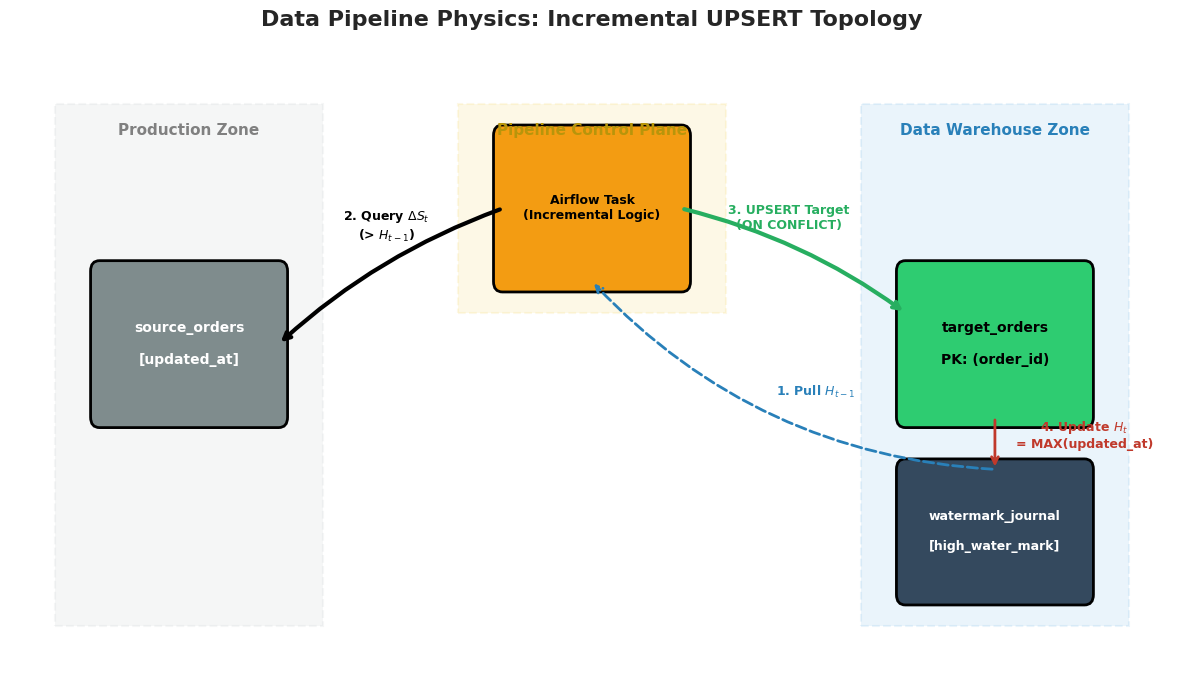

In [9]:
# Visualizing the Incremental Architecture
fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle("Data Pipeline Physics: Incremental UPSERT Topology", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. Define Topological Zones
# Source Zone
source_box = patches.Rectangle((0, 0.5), 3, 5, fill=True, color='#bdc3c7', alpha=0.15, edgecolor='black', linewidth=1.5, linestyle='--')
ax.add_patch(source_box)
ax.text(1.5, 5.2, "Production Zone", ha='center', color='gray', fontweight='bold', fontsize=11)

# Control Zone (Airflow / Pipeline Logic)
control_box = patches.Rectangle((4.5, 3.5), 3, 2, fill=True, color='#f1c40f', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--')
ax.add_patch(control_box)
ax.text(6, 5.2, "Pipeline Control Plane", ha='center', color='#b7950b', fontweight='bold', fontsize=11)

# Warehouse Zone
target_box = patches.Rectangle((9, 0.5), 3, 5, fill=True, color='#3498db', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--')
ax.add_patch(target_box)
ax.text(10.5, 5.2, "Data Warehouse Zone", ha='center', color='#2980b9', fontweight='bold', fontsize=11)

# 2. Draw Database Tables
# Source Table
ax.add_patch(patches.FancyBboxPatch((0.5, 2.5), 2.0, 1.4, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#7f8c8d'))
ax.text(1.5, 3.2, "source_orders\n\n[updated_at]", ha='center', va='center', color='white', fontweight='bold', fontsize=10)

# Target Table
ax.add_patch(patches.FancyBboxPatch((9.5, 2.5), 2.0, 1.4, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#2ecc71'))
ax.text(10.5, 3.2, "target_orders\n\nPK: (order_id)", ha='center', va='center', color='black', fontweight='bold', fontsize=10)

# Watermark Table
ax.add_patch(patches.FancyBboxPatch((9.5, 0.8), 2.0, 1.2, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#34495e'))
ax.text(10.5, 1.4, "watermark_journal\n\n[high_water_mark]", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

# Pipeline Logic Node
ax.add_patch(patches.FancyBboxPatch((5.0, 3.8), 2.0, 1.4, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#f39c12'))
ax.text(6.0, 4.5, "Airflow Task\n(Incremental Logic)", ha='center', va='center', color='black', fontweight='bold', fontsize=9)

# 3. Draw The Physics of Execution (Edges)
# Step 1: Read Watermark
ax.annotate("", xy=(6.0, 3.8), xytext=(10.5, 2.0), arrowprops=dict(arrowstyle="->", lw=2, color="#2980b9", linestyle="dashed", connectionstyle="arc3,rad=-0.2"))
ax.text(8.5, 2.7, "1. Pull $H_{t-1}$", ha='center', fontweight='bold', color="#2980b9", fontsize=9)

# Step 2: Extract Delta
ax.annotate("", xy=(5.0, 4.5), xytext=(2.5, 3.2), arrowprops=dict(arrowstyle="<-", lw=3, color="black", connectionstyle="arc3,rad=-0.1"))
ax.text(3.7, 4.2, "2. Query $\\Delta S_t$\n(> $H_{t-1}$)", ha='center', fontweight='bold', color="black", fontsize=9)

# Step 3: UPSERT to Target
ax.annotate("", xy=(9.5, 3.5), xytext=(7.0, 4.5), arrowprops=dict(arrowstyle="->", lw=3, color="#27ae60", connectionstyle="arc3,rad=-0.1"))
ax.text(8.2, 4.3, "3. UPSERT Target\n(ON CONFLICT)", ha='center', fontweight='bold', color="#27ae60", fontsize=9)

# Step 4: Advance Watermark
ax.annotate("", xy=(10.5, 2.0), xytext=(10.5, 2.5), arrowprops=dict(arrowstyle="->", lw=2, color="#c0392b", linestyle="solid"))
ax.text(11.5, 2.2, "4. Update $H_t$\n= MAX(updated_at)", ha='center', fontweight='bold', color="#c0392b", fontsize=9)

plt.xlim(-0.5, 12.5)
plt.ylim(0, 6)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of Incremental Data Loading like **Reading a 10,000-Page Novel**:

* **Full Refresh (The Amnesiac Reader)**: You decide to read 10 pages a night. On Day 1, you read pages 1-10. On Day 2, because you don't use a bookmark, you start over from the very beginning. You re-read pages 1-10, and finally read pages 11-20. By Day 300, you are reading 3,000 pages every single night just to get to the 10 new pages. This is computational suicide.
* **Incremental Load (The Bookmark)**: On Day 1, you read pages 1-10. You place a physical bookmark (The High-Water Mark / $H_t$) on page 10. You close the book (The database connection closes). On Day 2, your Airflow pipeline opens the book, explicitly looks for the bookmark (`SELECT high_water_mark`), completely skips the first 10 pages, and only reads the new Delta ($\Delta S_t$). You advance the bookmark to page 20, and the system shuts down.

By utilizing High-Water Marks and UPSERTs, an Enterprise can process 50 million updates a day inside a 10-billion row warehouse in mere seconds.